(105, 9) Index(['dataset', 'smiles (substrate)', 'substrate', 'smiles (pore side)',
       'pore side', 'SMILES to be used (molecules with a node)',
       'molecule with a node', 'capacitance_max', 'uwagi'],
      dtype='object')


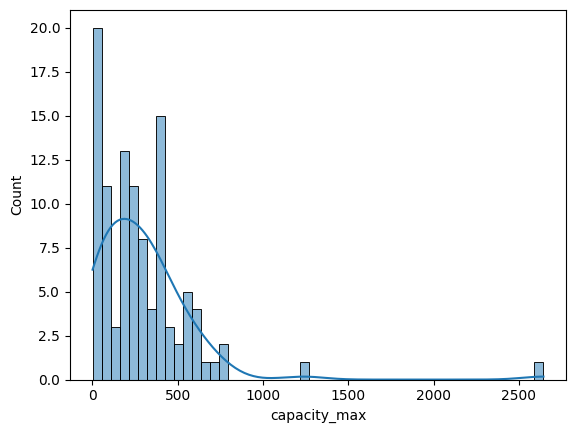

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_all = pd.read_excel('../data/data_battery_materials_20.06.xlsx')
print(df_all.shape, df_all.columns)
df_all = df_all[['dataset', 'smiles (substrate)', 'capacitance_max']].reset_index()
df_all.rename(columns={'smiles (substrate)': 'smiles', 'capacitance_max': 'capacity_max'}, inplace=True)

sns.histplot(data=df_all, x='capacity_max', bins=50, kde=True)
plt.show()

(103, 4)


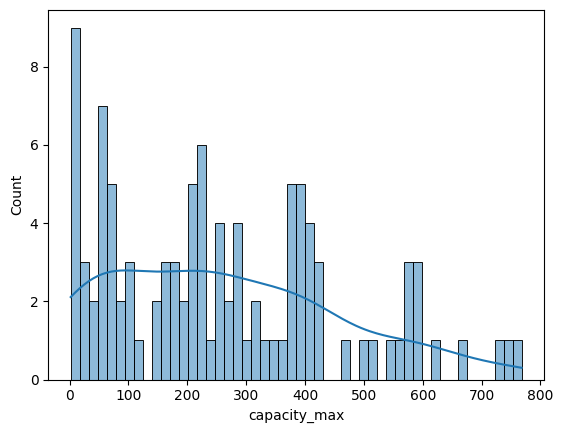

In [2]:
df_all = df_all[df_all['capacity_max'] > 0]
df_all = df_all[df_all['capacity_max'] < 1000]
print(df_all.shape)
sns.histplot(data=df_all, x='capacity_max', bins=50, kde=True)
plt.show()

In [3]:
from rdkit import Chem

rows_to_remove = []
for i, row in df_all.iterrows():
    smiles = row['smiles']
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        rows_to_remove.append(i)
df_all = df_all.drop(rows_to_remove).reset_index(drop=True)
df_all

[22:02:12] Explicit valence for atom # 4 N, 4, is greater than permitted


,index,dataset,smiles,capacity_max
0,0,expert1,N#CC1=CC=C(C#N)C=C1,628.0
1,1,expert1,CC(C1=CC=C(N2C3=C(C=C2C4=CC=C(C=C4)C#N)N(C5=CC...,255.0
2,2,expert1,CC1=CC2=C(N=C(S2)N3C(C4=CC=C(C=C4)C#N)=CC5=C3C...,269.0
3,3,expert1,ClC1=NC(C2=CC=C(C3=CC(C4=CC=C(C5=NC(Cl)=NC(Cl)...,228.0
4,4,expert1,ClC1=NC(Cl)=NC(NC2=CC3=C(C=C2)C(C4=C(C3=O)C=CC...,468.0
...,...,...,...,...
97,100,NaN,O=C1C(C2=C(C3=CC=C(/C=N/C4=CC=C(C5=CC(C6=CC=C(...,50.0
98,101,NaN,NC1=CC=C(C2=CC=C3C(C4(C5=C3C=CC(C6=CC=C(N)C=C6...,251.0
99,102,NaN,O=CC(C=C1)=CC=C1[Sb](C2=CC=C(/C=N/C3=CC=C(C4=C...,768.0
100,103,NaN,O=CC1=CC=C([Sb](C2=CC=C(C=C2)C=O)C3=CC=C(C=C3)...,393.0


In [4]:
from src.core.fingerprints import Fingerprints
df = df_all

names = ['ecfp', 'descriptor']
params = {
    'ecfp': {'radius': 2, 'size': 1024, 'count': True},
    'descriptor': {}
}
fingerprints, f_names = Fingerprints().apply(
    smiles=df['smiles'].tolist(),
    names=names,
    **params
)
df_fingerprints = pd.DataFrame(fingerprints, columns=f_names)
threshold = 0.85
df_fingerprints = df_fingerprints[[col for col in df_fingerprints.columns if df_fingerprints[col].value_counts(normalize=True).iloc[0] <= threshold]]
df_fingerprints = df_fingerprints.loc[:, df_fingerprints.nunique() > 1]
df_fingerprints['capacity_max'] = df['capacity_max'].values
df_fingerprints['smiles'] = df['smiles'].values

df_fingerprints

,ecfp_feature_25,ecfp_feature_33,ecfp_feature_39,ecfp_feature_45,ecfp_feature_98,ecfp_feature_112,ecfp_feature_116,ecfp_feature_128,ecfp_feature_136,ecfp_feature_144,...,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt,o%,n%,c%,capacity_max,smiles
0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,47.58,128.037448,0.000000,0.200000,0.800000,628.0,N#CC1=CC=C(C#N)C=C1
1,0.0,4.0,0.0,2.0,0.0,2.0,0.0,0.0,2.0,0.0,...,6.0,4.0,0.0,57.44,544.262697,0.000000,0.095238,0.904762,255.0,CC(C1=CC=C(N2C3=C(C=C2C4=CC=C(C=C4)C#N)N(C5=CC...
2,0.0,2.0,0.0,2.0,0.0,2.0,0.0,0.0,2.0,0.0,...,4.0,6.0,0.0,83.22,602.134737,0.000000,0.136364,0.818182,269.0,CC1=CC2=C(N=C(S2)N3C(C4=CC=C(C=C4)C#N)=CC5=C3C...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,...,6.0,9.0,0.0,116.01,746.958158,0.000000,0.187500,0.687500,228.0,ClC1=NC(C2=CC=C(C3=CC(C4=CC=C(C5=NC(Cl)=NC(Cl)...
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,4.0,10.0,2.0,135.54,531.952432,0.058824,0.235294,0.588235,468.0,ClC1=NC(Cl)=NC(NC2=CC3=C(C=C2)C(C4=C(C3=O)C=CC...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,0.0,2.0,1.0,0.0,1.0,0.0,1.0,0.0,6.0,4.0,...,22.0,8.0,4.0,122.09,913.405933,0.045455,0.075758,0.848485,50.0,O=C1C(C2=C(C3=CC=C(/C=N/C4=CC=C(C5=CC(C6=CC=C(...
98,4.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,8.0,6.0,...,7.0,5.0,6.0,107.49,796.320212,0.016129,0.064516,0.919355,251.0,NC1=CC=C(C2=CC=C3C(C4(C5=C3C=CC(C6=CC=C(N)C=C6...
99,6.0,0.0,2.0,0.0,4.0,0.0,0.0,0.0,2.0,0.0,...,8.0,6.0,4.0,112.98,634.085248,0.100000,0.050000,0.825000,768.0,O=CC(C=C1)=CC=C1[Sb](C2=CC=C(/C=N/C3=CC=C(C4=C...
100,6.0,0.0,2.0,0.0,4.0,0.0,1.0,0.0,2.0,2.0,...,8.0,4.0,2.0,72.52,602.095419,0.052632,0.052632,0.868421,393.0,O=CC1=CC=C([Sb](C2=CC=C(C=C2)C=O)C3=CC=C(C=C3)...


In [7]:
names_join = '_'.join(names)
df_fingerprints.to_csv(f'../data/cof_data/data_batteries_{names_join}.csv', index=False)

In [17]:
1/10 * (df_fingerprints['capacity_max'].max() - df_fingerprints['capacity_max'].min())

np.float64(76.60000000000001)